In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

In [11]:
# Stations that Armaan Analyzed
# Halibut Bank, HB: at coordinates [142,139] on HRDPS grid
# Sentry Shoal: SS: at coordinates [174,107] on HRDPS grid
# Sand Heads: SH: at coordinates [129,149] on HRDPS grid

In [3]:
variables = [['tair', 'tas', 'Near-Surface Air Temperature'], 
             ['precip', 'pr', 'Precipitation'], 
             ['atmpres', 'psl', 'Sea Level Pressure'], 
             ['qair', 'huss', 'Near Surface Specific Humidity'], 
             ['solar', 'rsds', 'Shortwave radiation'], 
             ['therm_rad', 'rlds', 'Longwave radiation'],
             ['u_wind', 'uas', 'u-winds'], 
             ['v_wind', 'vas', 'vas']]

In [12]:
# Armaan ran analysis based on 2007 and then used that to get 2008

In [6]:
##import results of previous runs
var = variables[2]
df = pd.read_csv('/ocean/arandhawa/MOAD/analysis-armaan/notebooks/recon08_' + var[0] + '.csv')
name = var[2]

HB = np.array(df['HB_hr'])
SS = np.array(df['SS_hr'])
SH = np.array(df['SH_hr'])
HB_rec = np.array(df['HB_recon'])
SS_rec = np.array(df['SS_recon'])
SH_rec = np.array(df['SH_recon'])

HB RMSE: 361.31590459158883 SS RMSE: 371.4161001898538 SH RMSE: 359.4533735568658
Average RMSE: 364.0617927794362


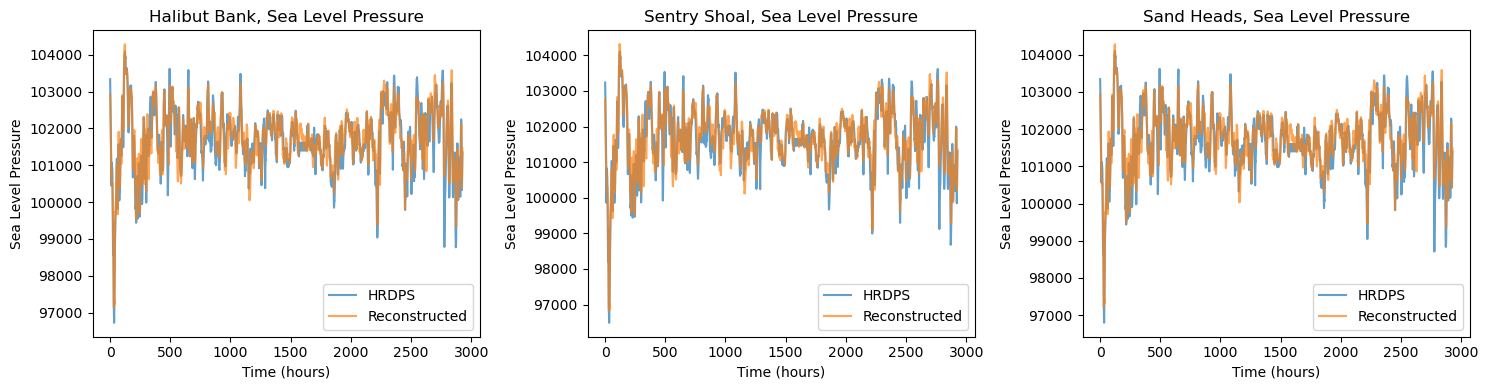

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
alpha_val = 0.7

ax[0].plot(HB, label = "HRDPS", alpha = alpha_val)
ax[0].plot(HB_rec, label = "Reconstructed", alpha = alpha_val)
ax[0].set_title("Halibut Bank, " + name)
ax[0].set_xlabel("Time (hours)")
ax[0].set_ylabel(name)
ax[0].legend()

ax[1].plot(SS, label = "HRDPS", alpha = alpha_val)
ax[1].plot(SS_rec, label = "Reconstructed", alpha = alpha_val)
ax[1].set_title("Sentry Shoal, " + name)
ax[1].set_xlabel("Time (hours)")
ax[1].set_ylabel(name)
ax[1].legend()

ax[2].plot(SH, label = "HRDPS", alpha = alpha_val)
ax[2].plot(SH_rec, label = "Reconstructed", alpha = alpha_val)
ax[2].set_title("Sand Heads, " + name)
ax[2].set_xlabel("Time (hours)")
ax[2].set_ylabel(name)
ax[2].legend()
print("HB RMSE:", np.sqrt( mean_squared_error(HB, HB_rec)), 
                            "SS RMSE:", np.sqrt( mean_squared_error(SS, SS_rec)), 
                                                  "SH RMSE:", np.sqrt( mean_squared_error(SH, SH_rec)))

avg_rmse = np.sqrt( mean_squared_error(HB, HB_rec)) + np.sqrt( mean_squared_error(SS, SS_rec)) + np.sqrt( mean_squared_error(SH, SH_rec))
avg_rmse = avg_rmse/3
print("Average RMSE:", avg_rmse)
plt.tight_layout()